In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import flpoAgent 
import importlib 
import random 
from scipy.spatial.distance import cdist 
import createEnv 
from scipy.optimize import Bounds, LinearConstraint, minimize 
import supporting_functions 
from matplotlib.cm import get_cmap 
import time

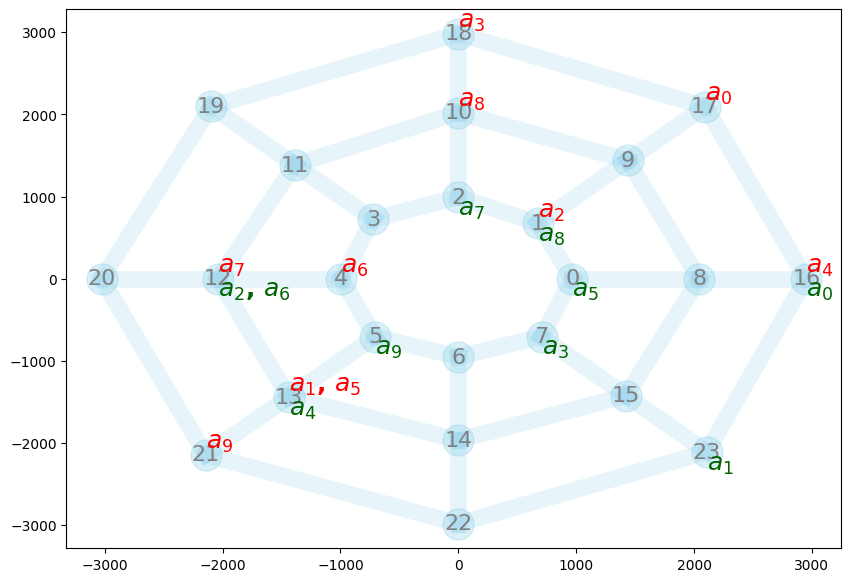

In [11]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 24
n_agents = 10
tolArray = np.random.uniform(10.0, 10.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':1000,
    'noise_factor':10
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# ellispoid cbf mode
ca_cbf_el = {
    'mode':'ellipse',
    'major_axis':1e-3*tolArray,
    'minor_axis':1e-4*tolArray,
    'degree':2
}

# linear cbf mode
ca_cbf_lin = {
    'mode':'linear',
    'eps':1e-4*tolArray,
    'eta':0
}

# cost mode options
cost_mode = 'sum' # 'slowest'
lm = 1 # for slowest

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    ring_params, 
    seed=11, 
    offset_energy=1,
    stagewiseCostCoeffs=np.array([1.0, 100.0, 1.0]),
    selfHop=0,
    ca_cbf=ca_cbf_lin,
    cost_mode=cost_mode,
    lm = lm,
    filter_wp_thresh=1e-10,
    prune_mode=False,
    printFlag=False)

# mars visualization 
cmap = plt.get_cmap('tab20') 
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))} 
createEnv.plotNetwork(mars=mars, figuresize=(10,7), routes=[], agent_colors=agent_colors, showEdgeLength=False) 

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [12]:
beta_min = 1e-5
beta_max = 1e3
beta_grow = 5
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow

T0 = mars.sched_mat
# T0 = np.ones((mars.n_agents, mars.n_waypoints))
# for i in range(mars.n_agents):
#     if i > 0:
#         T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0, 5, mars.tolArray.shape)
# T0 = np.random.uniform(0, 10, (mars.n_agents, mars.n_waypoints))
V0 = mars.speed_vec

optimizer_cbf_clf = {
    'name':'cbf_clf',
    'dt_init':0.01,
    'dt_min':1e-6,
    'dt_max':0.01,
    'Tf':10,
    'gamma':1,
    'alpha_s':100,
    'alpha_c':10,
    'alpha_r':100,
    'alpha_q':100,
    'p':1,
    'stop_tol':0.000005,
    'stop_tol_weight':np.array([0, 0, 1, 0]),
    'verbose':0
}

optimizer_slsqp = {
    'name':'SLSQP',
    'stop_tol':0.01,
    'disp':False
}

optimizers = [optimizer_cbf_clf, optimizer_slsqp]


In [13]:
mars.start_times

array([ 1.39756289, 29.28196597, 48.78928214, 43.06159622,  2.96243772,
       29.93769074, 30.91053991,  7.13045665, 34.67250403, 49.20896113])

In [14]:
mars.ca_cbf = ca_cbf_el
cbf_mode = mars.ca_cbf['mode']
active_waypoints = range(mars.n_waypoints)
mars.prune_mode = True 
mars.filter_wp_thresh = 0.01
mars.tolArray = np.random.uniform(5.0, 5.0, n_waypoints) 
print(f'mars cbf mode: {cbf_mode}')
print(f'pruning mode: {mars.prune_mode}')
print(beta_arr) 

for optim in optimizers:
    name = optim['name']
    print(f'--------------------------------------') 
    print(f'       solving using {name}           ') 
    print(f'--------------------------------------') 

    t0 = time.time()
    T, V, F, Pb_a = mars.anneal( 
        beta_arr, 
        T0, 
        V0, 
        active_waypoints=active_waypoints, 
        optimizer=optim, 
        annealPrint=True) 
    t1 = time.time()
    optim['T_final'] = T 
    optim['V_final'] = V 
    optim['F_final'] = F 
    optim['Pb_a_final'] = Pb_a 
    optim['runtime'] = t1 - t0
    



mars cbf mode: ellipse
pruning mode: True
[1e-05, 5e-05, 0.00025, 0.00125, 0.00625, 0.03125, 0.15625, 0.78125, 3.90625, 19.53125, 97.65625, 488.28125]
--------------------------------------
       solving using cbf_clf           
--------------------------------------
a:0.000	b:2.500

beta: 1.0000e-05	cost: 196497.581	tolb: 2.103e-08	n_active_waypoints:24	tol_mag:5.00	Hbshape:(162,)
a:7.766	b:3.821

beta: 5.0000e-05	cost: 53031.818	tolb: 4.568e-06	n_active_waypoints:24	tol_mag:5.00	Hbshape:(242,)
a:27.705	b:4.356

beta: 2.5000e-04	cost: 13214.614	tolb: 4.508e-06	n_active_waypoints:24	tol_mag:5.00	Hbshape:(89,)
a:53.071	b:4.602

beta: 1.2500e-03	cost: 3594.161	tolb: 4.955e-06	n_active_waypoints:24	tol_mag:5.00	Hbshape:(46,)
a:78.168	b:4.732

beta: 6.2500e-03	cost: 1350.826	tolb: 4.336e-06	n_active_waypoints:24	tol_mag:5.00	Hbshape:(39,)
a:100.100	b:4.808

beta: 3.1250e-02	cost: 853.988	tolb: 1.417e-06	n_active_waypoints:24	tol_mag:5.00	Hbshape:(37,)
a:118.113	b:4.856

beta: 1.5625e-01	c

/Users/dhananjaytiwari/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)



beta: 1.0000e-05	cost: 198763.812	tol_mag:5.00
a:7.766	b:3.821

beta: 5.0000e-05	cost: 53125.881	tol_mag:5.00
a:27.705	b:4.356

beta: 2.5000e-04	cost: 13176.543	tol_mag:5.00
a:53.071	b:4.602

beta: 1.2500e-03	cost: 3531.688	tol_mag:5.00
a:78.168	b:4.732

beta: 6.2500e-03	cost: 1254.540	tol_mag:5.00
a:100.100	b:4.808

beta: 3.1250e-02	cost: 715.539	tol_mag:5.00
a:118.113	b:4.856

beta: 1.5625e-01	cost: 606.585	tol_mag:5.00
a:132.496	b:4.888

beta: 7.8125e-01	cost: 584.904	tol_mag:5.00
a:160.813	b:4.988

beta: 3.9062e+00	cost: 580.834	tol_mag:5.00
a:170.768	b:4.991

beta: 1.9531e+01	cost: 580.017	tol_mag:5.00
a:177.807	b:4.993

beta: 9.7656e+01	cost: 579.879	tol_mag:5.00
a:182.851	b:4.995

beta: 4.8828e+02	cost: 579.868	tol_mag:5.00


--------------------------------
       cbf_clf results           
--------------------------------
final_cost:727.55
runtime:71.01
+----+---------------------------+----------------------------------------------------+-------+--------+-------+-----------------------+---------+
| A  |             R             |                         T                          |   V   | V Mean | V Max |         V Lim         |  Cost   |
+----+---------------------------+----------------------------------------------------+-------+--------+-------+-----------------------+---------+
| v0 |         [16, 17]          |                [ 1.4   1.4  32.82]                 | 72.04 | 72.04  | 72.04 |     [ 0.59 72.04]     | 986.88  |
| v1 |   [23, 15, 7, 6, 5, 13]   |    [29.28 30.34 42.67 55.58 65.09 74.6  87.79]     | 78.64 | 78.59  | 78.63 |     [ 0.74 78.64]     | 673.95  |
| v2 |     [12, 4, 3, 2, 1]      |       [48.79 49.7  64.35 75.13 85.94 96.38]        | 71.55 | 71.52  | 71.54 |     [ 0.68 71.55]   

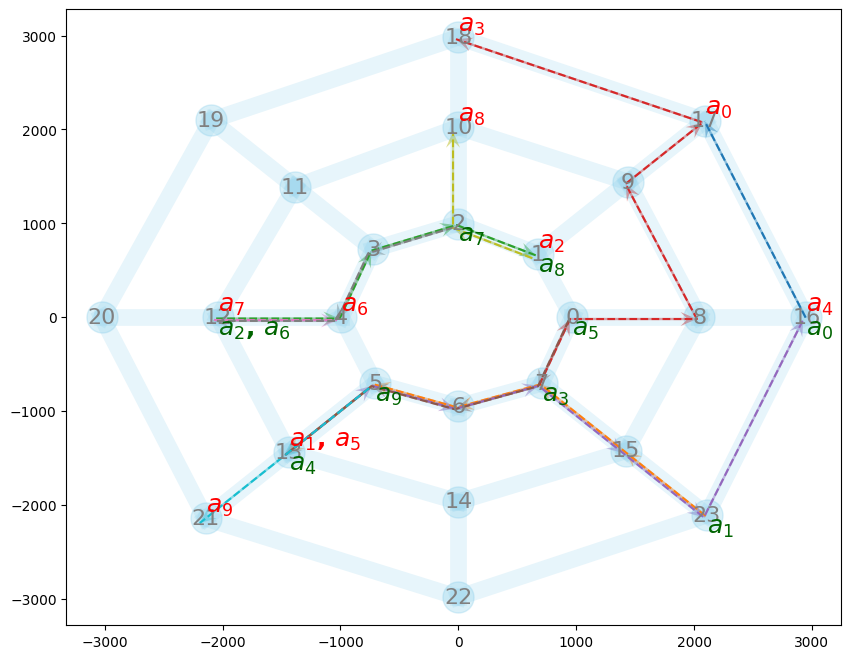

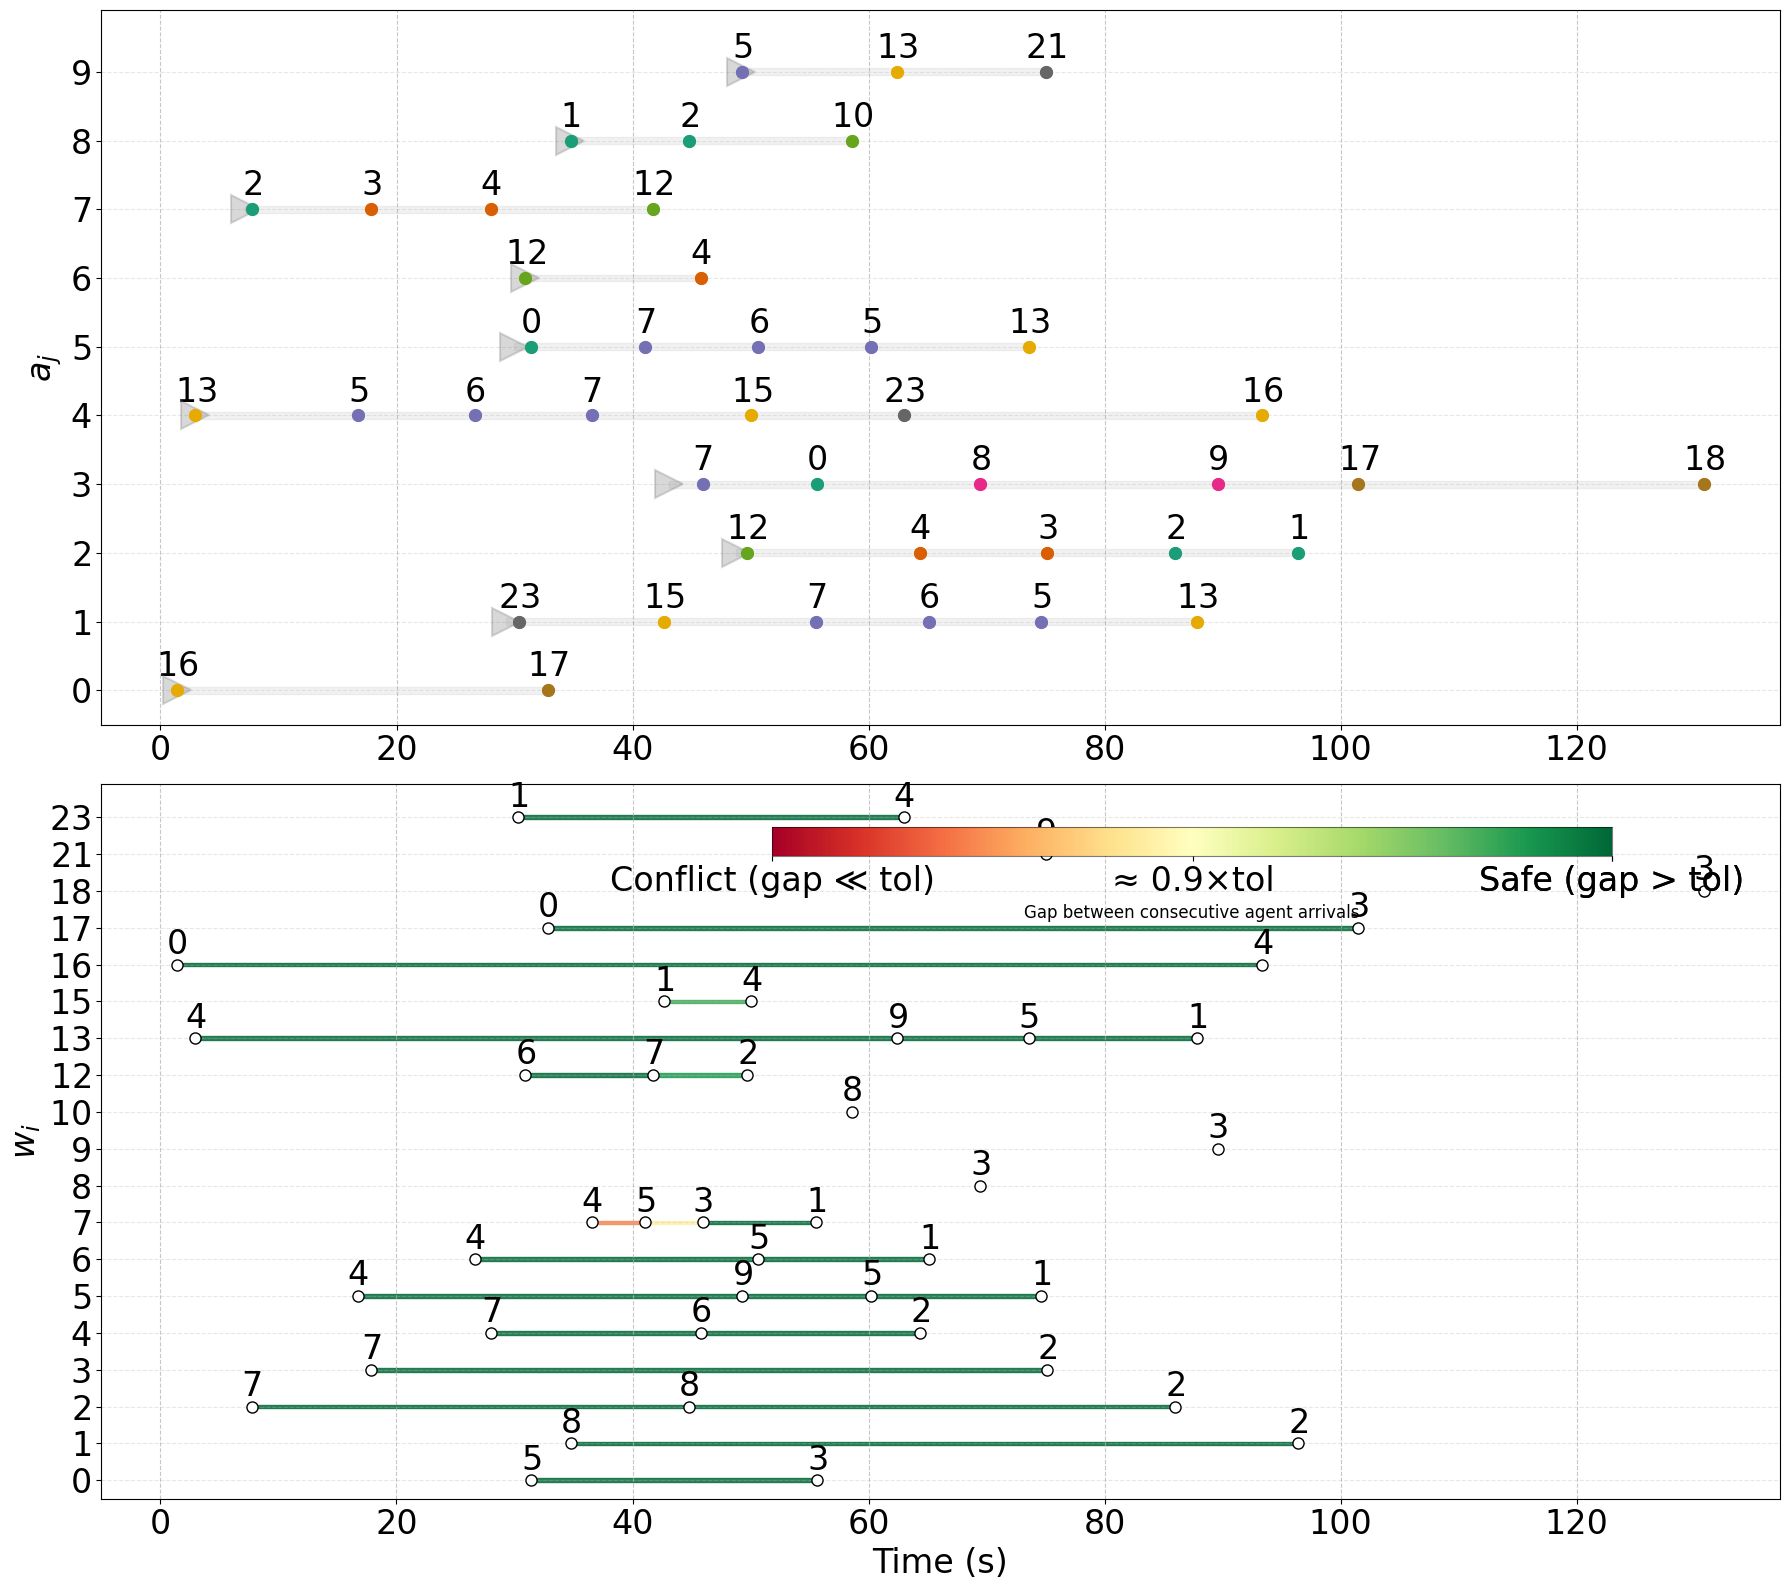

--------------------------------
       SLSQP results           
--------------------------------
final_cost:579.87
runtime:1332.66
+----+-------------------------------+------------------------------------------------------------------+-------+--------+-------+-----------------------+---------+
| A  |               R               |                                T                                 |   V   | V Mean | V Max |         V Lim         |  Cost   |
+----+-------------------------------+------------------------------------------------------------------+-------+--------+-------+-----------------------+---------+
| v0 |           [16, 17]            |                       [ 1.4   1.4  32.81]                        | 72.04 | 72.04  | 72.04 |     [ 0.59 72.04]     | 986.87  |
| v1 |     [23, 15, 7, 6, 5, 13]     |           [29.28 29.28 41.6  54.5  64.01 73.51 86.7 ]            | 78.64 | 78.64  | 78.64 |     [ 0.74 78.64]     | 672.80  |
| v2 |       [12, 4, 3, 2, 1]        |     

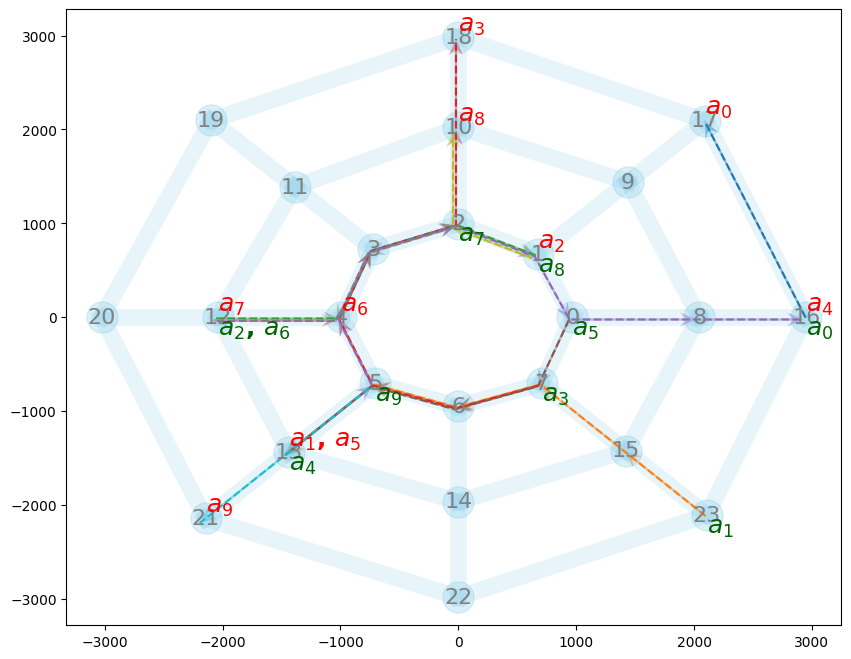

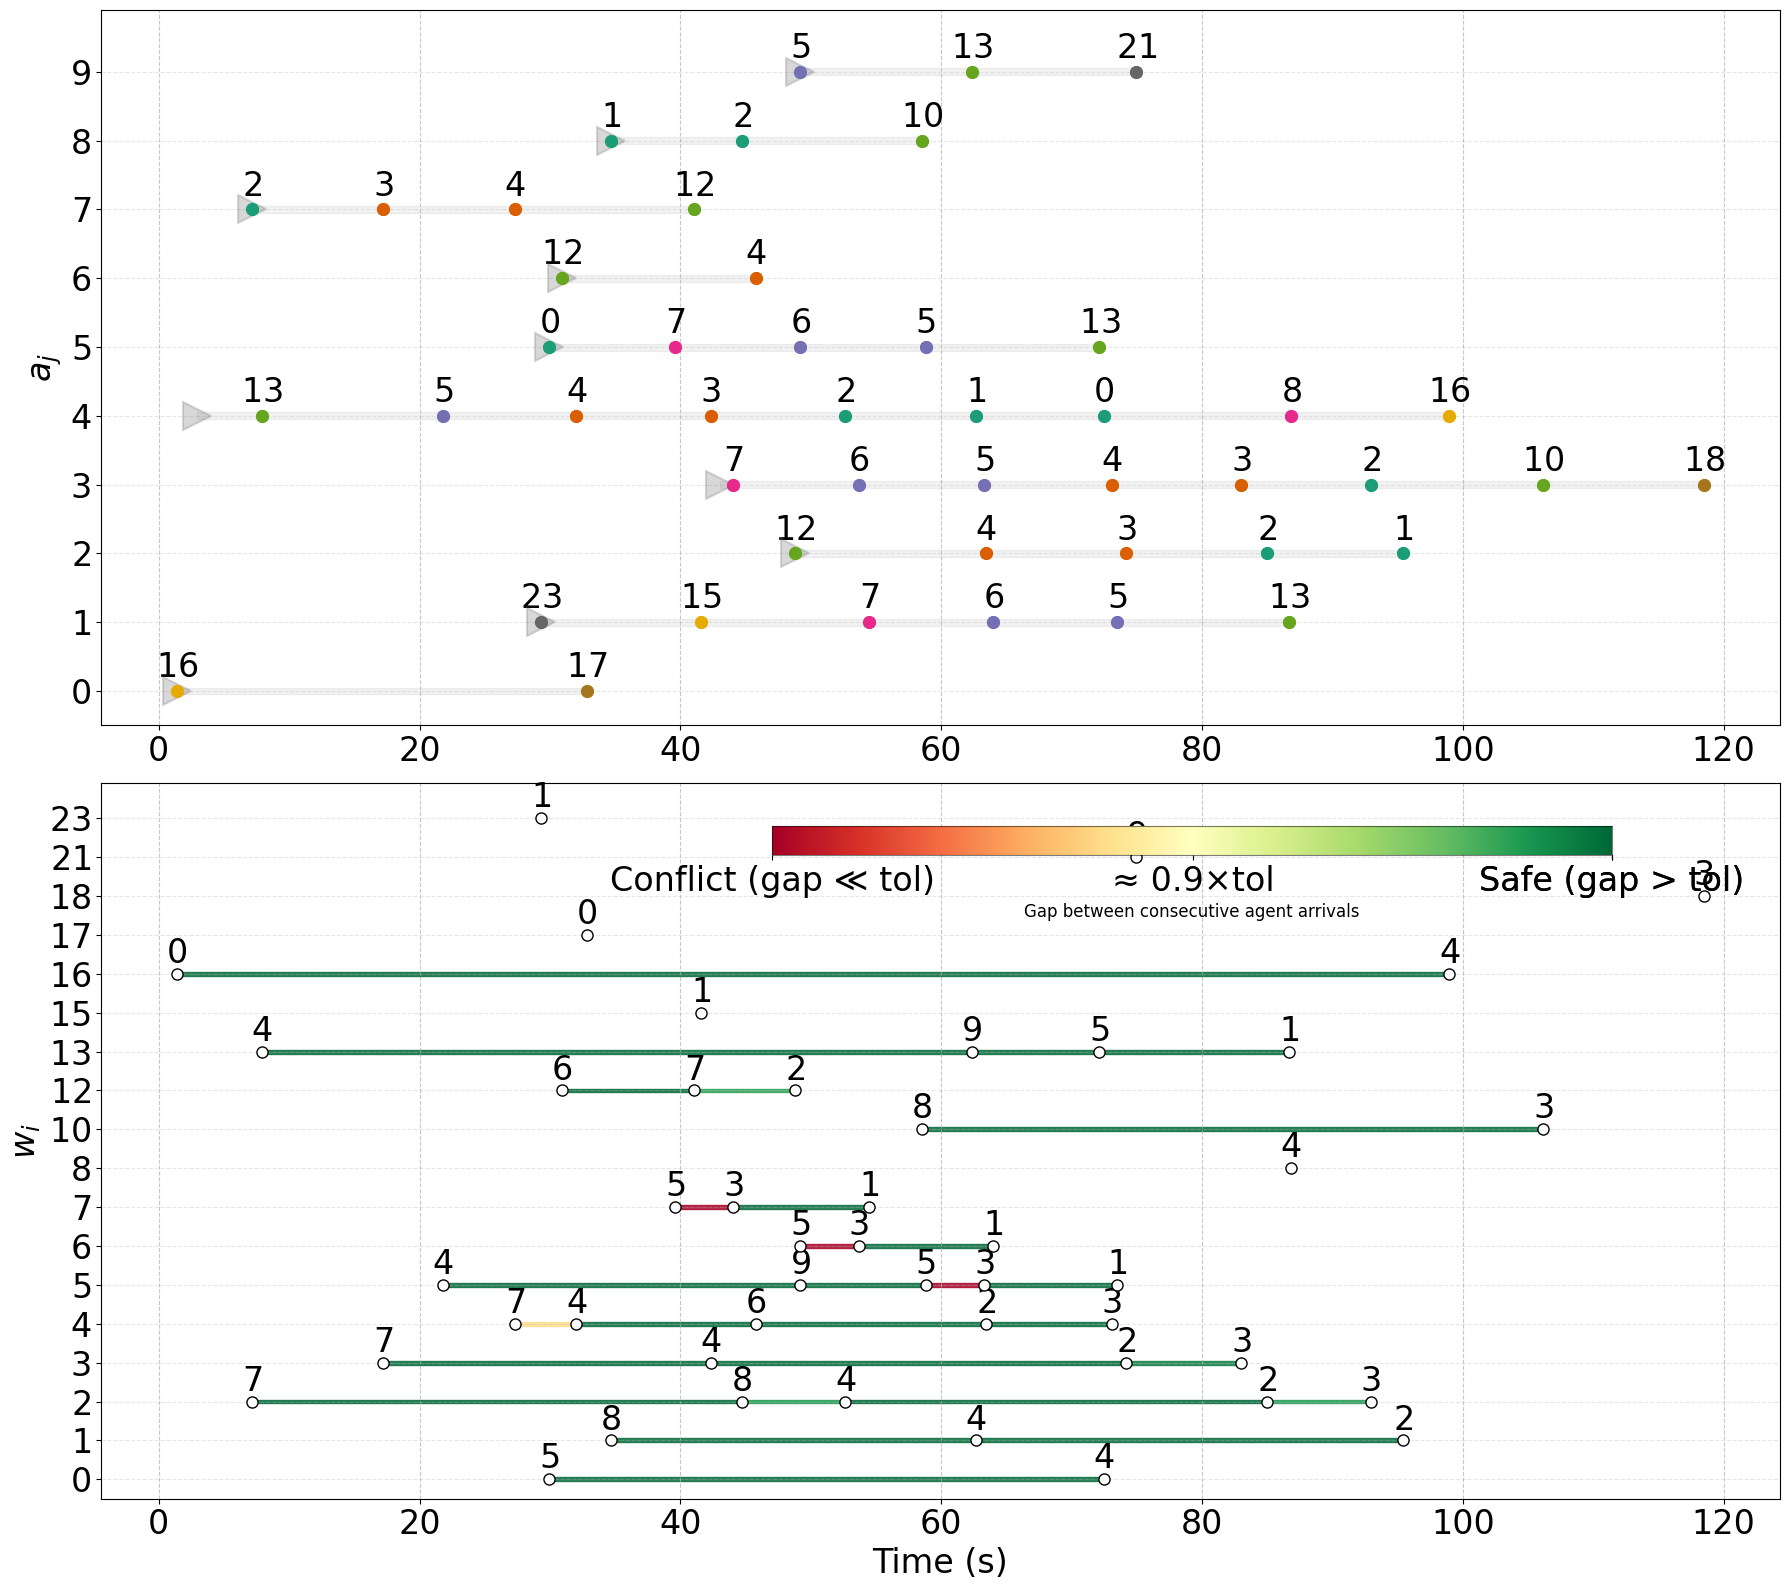

In [17]:
importlib.reload(createEnv)

for optim in optimizers:
    name = optim['name']
    mars.sched_mat = optim['T_final']
    mars.speed_vec = optim['V_final']
    Pb_a = optim['Pb_a_final']
    F = optim['F_final']
    runtime = optim['runtime']

    print(f'--------------------------------')
    print(f'       {name} results           ')
    print(f'--------------------------------')

    print(f'final_cost:{F:.2f}')
    print(f'runtime:{runtime:.2f}')

    agent_routes, agent_schedules = createEnv.show_solution_table( 
        mars, 
        Pb_a, 
        beta=beta_arr[-1], 
        printRoutes=True)
        
    createEnv.plotNetwork(
        mars=mars, 
        figuresize=(10,8), 
        routes=agent_routes, 
        agent_colors=agent_colors, 
        showEdgeLength=False) 

    reach_mat = mars.calc_agent_reach_mat_v1(
        mars.sched_mat,
        mars.speed_vec,
        beta=beta_arr[-1]
    )

    association_mat = np.ones(shape=reach_mat.shape)
    association_mat[reach_mat <= 1e-10] = 0.0

    createEnv.plot_waypoint_agent_schedules(
        agent_routes,
        agent_schedules,
        mars.sched_mat,
        association_mat,
        mars.process_T,
        mars.tolArray,
        agent_colors,
        figuresize=(18,16),
        bar_thickness=0.05,
        marker_size=8,
        start_marker_size=20,
        index_size=24,
        x_tick_size=24,
        y_tick_size=24,
        x_label_size=24,
        y_label_size=24
    )

